# 05 — MPC Framework: Receding-Horizon HVAC Optimisation

**Project:** A Data-Driven Predictive Control Framework for HVAC Cooling Optimisation in Commercial Office Buildings

## Overview

This notebook implements a **Model Predictive Control (MPC)** framework for HVAC energy optimisation across three climate zones and two seasons.

**Two-component predictive engine:**
1. **XGBoost v2** (`model_xgb_v2.pkl`) — predicts baseline HVAC electricity demand (kWh) given outdoor conditions, occupancy, and time. Used as the energy cost term in the MPC objective.
2. **RC thermal model** — a simple 3-parameter linear model fitted from the dataset that predicts indoor temperature response to HVAC changes. Provides the state dynamics for the MPC.

**MPC formulation:**
- Control variable: `u(t) ∈ [0.5, 1.5]` — multiplier on baseline HVAC output
- Planning horizon: H = 6 steps (60 minutes)
- Cost function: `Σ [ w_T·(T_indoor − 22)² + w_E·u·hvac_predicted ]`
- Optimiser: `scipy.optimize.minimize` with L-BFGS-B

**Baseline:** thermostat-only control (`u = 1` always).

**Evaluation:** 4 simulation windows — Miami July, San Francisco July, Chicago July, Chicago January — demonstrating performance across cooling-dominated and heating-dominated conditions.

## 1. Imports & Constants

In [1]:
import json
import joblib
import warnings
from pathlib import Path
from collections import deque
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_IN = Path('../data/processed')
FIG_OUT = Path('../figures')
FIG_OUT.mkdir(parents=True, exist_ok=True)

# ── Thermal comfort constants ──────────────────────────────────────────────────
SETPOINT      = 23.5   # °C target indoor temperature
COMFORT_LOW   = 23.0   # °C lower comfort bound
COMFORT_HIGH  = 24.0   # °C upper comfort bound
COMFORT_BANDS = {'1A': (23.0, 25.0), '3C': (23.0, 24.0), '5A': (23.0, 24.0)}  # per-climate
SETPOINTS     = {'1A': 24.0, '3C': 23.5, '5A': 23.5}                           # per-climate MPC target

# ── MPC parameters ────────────────────────────────────────────────────────────
MPC_HORIZON   = 12     # planning horizon (12 steps = 120 min)
U_MIN, U_MAX  = 0.5, 1.5   # HVAC multiplier bounds
W_TEMP        = 50.0   # comfort penalty weight
W_ENERGY      = 1.0    # energy penalty weight
STEPS_PER_DAY = 144    # 10-min steps per day

# ── Climate metadata ──────────────────────────────────────────────────────────
CLIMATE_COLOURS = {'1A': '#E24B4A', '3C': '#2E75B6', '5A': '#639922'}
CLIMATE_LABELS  = {'1A': 'Miami (1A)', '3C': 'San Francisco (3C)', '5A': 'Chicago (5A)'}

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

print('Setup complete.')

Setup complete.


## 2. Load Models, Scalers & Feature Metadata

In [2]:
# ── Load XGBoost model & scalers ─────────────────────────────────────────────
xgb_model = joblib.load(DATA_IN / 'model_xgb_v2.pkl')
scaler_X  = joblib.load(DATA_IN / 'scaler_X_v2.pkl')
scaler_y  = joblib.load(DATA_IN / 'scaler_y_v2.pkl')

# ── Feature lists ─────────────────────────────────────────────────────────────
with open(DATA_IN / 'feature_sets_v2.json') as f:
    fs = json.load(f)

FULL_FEATURES_V2 = fs['FULL_FEATURES']            # 34 features (model input)
SCALE_COLS       = list(scaler_X.feature_names_in_)  # 20 continuous cols to scale

assert xgb_model.n_features_in_ == 34, f"Expected 34 features, got {xgb_model.n_features_in_}"
assert len(FULL_FEATURES_V2) == 34

print(f'XGBoost model loaded  : {xgb_model.n_features_in_} input features')
print(f'scaler_X fitted on    : {len(SCALE_COLS)} continuous columns')
print(f'scaler_y mean         : {scaler_y.mean_[0]:.4f} kWh')
print(f'scaler_y scale        : {scaler_y.scale_[0]:.4f} kWh')
print(f'\nFULL_FEATURES_V2 ({len(FULL_FEATURES_V2)}):')
print(' ', FULL_FEATURES_V2)

XGBoost model loaded  : 34 input features
scaler_X fitted on    : 20 continuous columns
scaler_y mean         : 3.6917 kWh
scaler_y scale        : 4.1249 kWh

FULL_FEATURES_V2 (34):
  ['oat_c', 'wetbulb_c', 'oat_roll1h', 'oat_roll3h', 'oat_dev', 'wetbulb_dev', 'oat_sq', 'indoor_temp_c', 'indoor_dev', 'occupancy', 'is_occupied', 'lighting_kwh', 'plugloads_kwh', 'hvac_lag1', 'hvac_lag6', 'hvac_lag144', 'hvac_roll1h', 'hvac_roll24h', 'hour', 'dayofweek', 'month', 'is_weekday', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'climate_1A', 'climate_3C', 'climate_5A', 'efficiency_High', 'efficiency_Low', 'efficiency_Standard']


## 3. Load Simulation Data

In [3]:
# ── 2004 data for MPC simulation (Standard efficiency, run_1) ─────────────────
# Timestamps use 2006 as reference year regardless of AMY year
sim_data = {}
for clim in ['1A', '3C', '5A']:
    df = pd.read_parquet(DATA_IN / f'multi_year_2004_{clim}.parquet')
    sim_data[clim] = df[(df['efficiency'] == 'Standard') & (df['run'] == 'run_1')].copy()
    print(f'sim_data[{clim!r}]: {len(sim_data[clim]):,} rows | '
          f'{sim_data[clim].index[0].date()} → {sim_data[clim].index[-1].date()}')

# ── 1990+1997 raw data for RC thermal model fitting ───────────────────────────
print('\nLoading RC training data (1990+1997)...')
rc_raw = {}
for clim in ['1A', '3C', '5A']:
    dfs = []
    for yr in ['1990', '1997']:
        df = pd.read_parquet(DATA_IN / f'multi_year_{yr}_{clim}.parquet')
        dfs.append(df)
    rc_raw[clim] = pd.concat(dfs).reset_index()
    print(f'rc_raw[{clim!r}]: {len(rc_raw[clim]):,} rows | '
          f'efficiency levels: {rc_raw[clim]["efficiency"].unique().tolist()}')

sim_data['1A']: 52,560 rows | 2006-01-01 → 2006-12-31
sim_data['3C']: 52,560 rows | 2006-01-01 → 2006-12-31
sim_data['5A']: 52,560 rows | 2006-01-01 → 2006-12-31

Loading RC training data (1990+1997)...
rc_raw['1A']: 946,080 rows | efficiency levels: ['Low', 'Standard', 'High']
rc_raw['3C']: 946,080 rows | efficiency levels: ['Low', 'Standard', 'High']
rc_raw['5A']: 946,080 rows | efficiency levels: ['Low', 'Standard', 'High']


## 4. RC Thermal Model

A linear ARX-style model predicts indoor temperature one step ahead from:
- **Thermal persistence:** building retains heat across time steps
- **Envelope heat transfer:** conductive exchange with outdoor air
- **HVAC effect:** cooling reduces temperature (β_cool < 0); heating increases it
- **Internal gains:** occupant body heat warms the space
- **Diurnal solar proxy:** hour_sin / hour_cos capture the building's daily solar
  gain cycle — solar radiation warms the building during daytime and dissipates
  at night, independently of mechanical HVAC

**Formula:**
```
T(t+1) = intercept
        + α_persist  · T(t)
        + α_env      · (OAT(t) − T(t))
        + β_cool     · hvac_cool(t)       [< 0: OAT > 22°C]
        + β_heat     · hvac_heat(t)       [OAT ≤ 22°C]
        + γ_occ      · occupancy(t)
        + δ_hs       · sin(2π·hour/24)
        + δ_hc       · cos(2π·hour/24)
```

Fitted separately per climate on 1990+1997 training data.
`β_cool` is sign-corrected after OLS: the reactive thermostat creates a spurious
positive raw correlation, so `β_cool = −|β_cool_OLS|` is enforced from physics.


In [4]:
def fit_rc_model(climate_df, climate_label):
    """
    Fit RC thermal model for one climate from multi-year raw data.

    Features (7):
        T(t)               — thermal persistence
        OAT(t) − T(t)     — envelope conduction
        hvac_cool(t)       — cooling effect  (hvac_kwh when OAT > SPLIT_OAT)
        hvac_heat(t)       — heating effect  (hvac_kwh when OAT ≤ SPLIT_OAT)
        occupancy(t)       — internal heat gains
        hour_sin(t)        — diurnal solar proxy (sine component)
        hour_cos(t)        — diurnal solar proxy (cosine component)

    Groups by (efficiency, run, year) to avoid cross-simulation bleed.
    Uses total hvac_kwh split by OAT threshold — consistent with simulation.
    """
    X_rows, y_rows = [], []
    SPLIT_OAT = 22.0   # threshold: cooling above, heating at or below

    groups = climate_df.groupby(['efficiency', 'run', 'year'])
    for (eff, run, yr), grp in groups:
        grp = grp.sort_index() if isinstance(grp.index, pd.DatetimeIndex) else grp
        if len(grp) < 2:
            continue

        T_in  = grp['indoor_temp_c'].values
        oat   = grp['oat_c'].values
        occ   = grp['occupancy'].values
        hvac  = grp['hvac_kwh'].values
        hour  = grp['hour'].values          # 0–23 integer column

        # Diurnal features: capture solar gain + building thermal cycle
        hour_sin = np.sin(2 * np.pi * hour / 24)
        hour_cos = np.cos(2 * np.pi * hour / 24)

        # Split total HVAC by OAT — same logic as simulation rc_step calls
        hvac_cool = np.where(oat[:-1] > SPLIT_OAT, hvac[:-1], 0.0)
        hvac_heat = np.where(oat[:-1] <= SPLIT_OAT, hvac[:-1], 0.0)

        X_rows.append(np.column_stack([
            T_in[:-1],              # alpha_persist
            oat[:-1] - T_in[:-1],  # alpha_env  (envelope conduction)
            hvac_cool,              # beta_cool  (total HVAC, cooling season)
            hvac_heat,              # beta_heat  (total HVAC, heating season)
            occ[:-1],               # gamma_occ  (internal gains)
            hour_sin[:-1],          # delta_hour_sin (diurnal solar)
            hour_cos[:-1],          # delta_hour_cos
        ]))
        y_rows.append(T_in[1:])

    X = np.vstack(X_rows)
    y = np.concatenate(y_rows)

    lr     = LinearRegression().fit(X, y)
    coefs  = lr.coef_
    y_pred = lr.predict(X)
    r2     = r2_score(y, y_pred)
    rmse   = np.sqrt(mean_squared_error(y, y_pred))

    # Sign correction: beta_cool must be negative (more cooling → lower T)
    beta_cool_corr = -abs(float(coefs[2]))

    return {
        'alpha_persist'  : float(coefs[0]),
        'alpha_env'      : float(coefs[1]),
        'beta_cool'      : beta_cool_corr,
        'beta_heat'      : float(coefs[3]),
        'gamma_occ'      : float(coefs[4]),
        'delta_hour_sin' : float(coefs[5]),
        'delta_hour_cos' : float(coefs[6]),
        'intercept'      : float(lr.intercept_),
        'r2'             : r2,
        'rmse'           : rmse,
        'n_samples'      : len(y),
    }


# ── Fit one RC model per climate ─────────────────────────────────────────────
print('Fitting RC thermal models (with diurnal features)...')
rc_models = {}
for clim in ['1A', '3C', '5A']:
    rc_models[clim] = fit_rc_model(rc_raw[clim], clim)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"Climate":<22} {"α_env":>8} {"β_cool":>10} {"β_heat":>10} '
      f'{"γ_occ":>8} {"sin_h":>8} {"cos_h":>8} {"R²":>7} {"RMSE":>7}')
print('-' * 96)
for clim, m in rc_models.items():
    print(f'{CLIMATE_LABELS[clim]:<22} {m["alpha_env"]:>8.5f} {m["beta_cool"]:>10.6f} '
          f'{m["beta_heat"]:>10.6f} {m["gamma_occ"]:>8.5f} '
          f'{m["delta_hour_sin"]:>8.5f} {m["delta_hour_cos"]:>8.5f} '
          f'{m["r2"]:>7.4f} {m["rmse"]:>7.4f}')


Fitting RC thermal models (with diurnal features)...

Climate                   α_env     β_cool     β_heat    γ_occ    sin_h    cos_h      R²    RMSE
------------------------------------------------------------------------------------------------
Miami (1A)              0.00041  -0.013733   0.019576 -0.00036 -0.01595  0.06960  0.9139  0.1986
San Francisco (3C)      0.00279  -0.004400   0.008508  0.00005  0.00174  0.02151  0.9826  0.1089
Chicago (5A)            0.00203  -0.003363   0.003988  0.00005  0.00156  0.01212  0.9929  0.1346


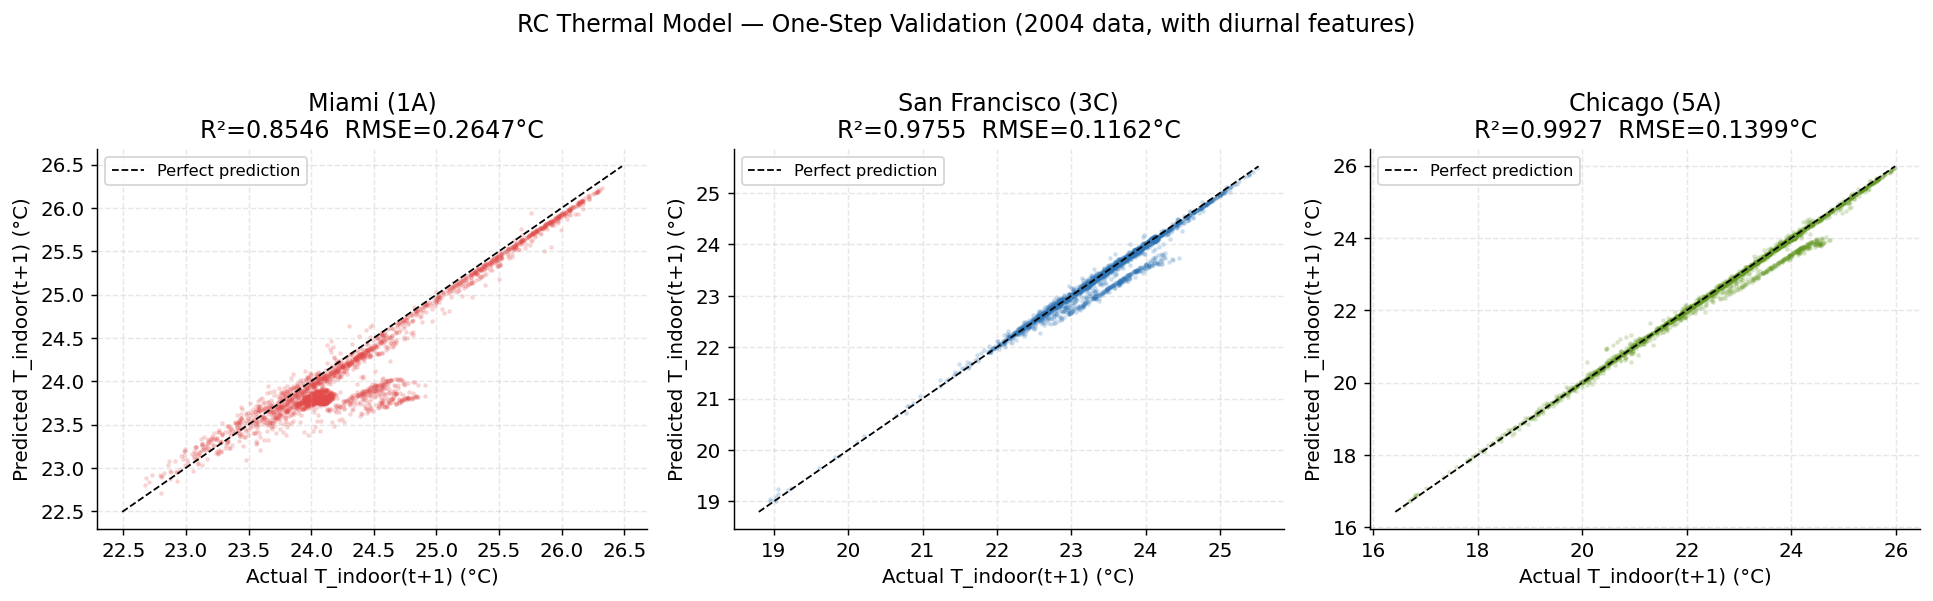

Saved → figures/05_rc_validation.png


In [5]:
# ── RC step function ────────────────────────────────────────────────────────
def rc_step(T, oat_c, hvac_cool, hvac_heat, occupancy, coefs, hour=12):
    """
    One-step RC temperature prediction.

    Parameters
    ----------
    T        : current indoor temperature (°C)
    oat_c    : outdoor air temperature (°C)
    hvac_cool: HVAC kWh allocated to cooling (0 in heating season)
    hvac_heat: HVAC kWh allocated to heating (0 in cooling season)
    occupancy: occupant count
    coefs    : dict of fitted RC model coefficients
    hour     : hour of day (0–23); used for diurnal solar proxy
    """
    hs = np.sin(2 * np.pi * hour / 24)
    hc = np.cos(2 * np.pi * hour / 24)
    return (coefs['intercept']
          + coefs['alpha_persist']   * T
          + coefs['alpha_env']       * (oat_c - T)
          + coefs['beta_cool']       * hvac_cool   # negative — cooling removes heat
          + coefs['beta_heat']       * hvac_heat
          + coefs['gamma_occ']       * occupancy
          + coefs['delta_hour_sin']  * hs
          + coefs['delta_hour_cos']  * hc)


SPLIT_OAT = 22.0   # OAT threshold — consistent with fit_rc_model

# ── Validate RC model on 2004 data using hvac_kwh split by OAT ──────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, clim in zip(axes, ['1A', '3C', '5A']):
    df_v  = sim_data[clim]
    c     = rc_models[clim]

    T_cur  = df_v['indoor_temp_c'].values[:-1]
    oat    = df_v['oat_c'].values[:-1]
    hvac   = df_v['hvac_kwh'].values[:-1]
    occ    = df_v['occupancy'].values[:-1]
    hour   = df_v['hour'].values[:-1]          # hour column
    T_next_actual = df_v['indoor_temp_c'].values[1:]

    hvac_cool = np.where(oat > SPLIT_OAT, hvac, 0.0)
    hvac_heat = np.where(oat <= SPLIT_OAT, hvac, 0.0)

    T_next_pred = np.array([
        rc_step(T_cur[i], oat[i], hvac_cool[i], hvac_heat[i], occ[i], c, hour=hour[i])
        for i in range(len(T_cur))
    ])

    r2   = r2_score(T_next_actual, T_next_pred)
    rmse = np.sqrt(mean_squared_error(T_next_actual, T_next_pred))

    ax.scatter(T_next_actual[::20], T_next_pred[::20], alpha=0.15, s=3,
               color=CLIMATE_COLOURS[clim])
    lims = [min(T_next_actual.min(), T_next_pred.min()),
            max(T_next_actual.max(), T_next_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1, label='Perfect prediction')
    ax.set_xlabel('Actual T_indoor(t+1) (°C)')
    ax.set_ylabel('Predicted T_indoor(t+1) (°C)')
    ax.set_title(f'{CLIMATE_LABELS[clim]}\nR²={r2:.4f}  RMSE={rmse:.4f}°C')
    ax.legend(fontsize=9)

plt.suptitle('RC Thermal Model — One-Step Validation (2004 data, with diurnal features)', y=1.02)
plt.tight_layout()
fig.savefig(FIG_OUT / '05_rc_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/05_rc_validation.png')


## 4b. ML Dynamics Temperature Model

Instead of the physics-derived RC model, we train a **data-driven plant model**:
a supervised XGBoost that learns T(t+1) directly from observed state variables.

**Input features (9):**
| Feature | Physical meaning |
|---------|------------------|
| T_indoor(t) | Thermal persistence — dominant signal |
| OAT(t) | Outdoor driving temperature |
| hvac_kwh(t) | Mechanical input — the MPC control variable |
| occupancy(t) | Internal heat gains from people |
| sin(2π·h/24), cos(2π·h/24) | Diurnal solar cycle |
| sin(2π·m/12), cos(2π·m/12) | Seasonal solar angle variation |
| OAT(t)−T(t) | Envelope driving force (heat flow direction) |

**Target:** T_indoor(t+1)

One model is trained per climate on 1990+1997 data, grouped by (efficiency, run, year).
No HVAC cooling/heating split is required — the model infers direction from context.
Validated on 2004 hold-out data.


In [ ]:
# ── Feature specification ─────────────────────────────────────────────────────
ML_TEMP_FEATURES = [
    'indoor_temp_c',   # T(t)          — thermal persistence
    'oat_c',           # OAT(t)        — outdoor conditions
    'hvac_kwh',        # HVAC(t)       — the control variable
    'occupancy',       # occ(t)        — internal heat gains
    'hour_sin',        # sin(2π·h/24)  — diurnal solar proxy
    'hour_cos',        # cos(2π·h/24)
    'month_sin',       # sin(2π·m/12)  — seasonal solar angle
    'month_cos',       # cos(2π·m/12)
    'oat_minus_T',     # OAT−T(t)      — envelope driving force
]
N_TEMP_FEAT = len(ML_TEMP_FEATURES)   # 9


def build_ml_temp_data(climate_df):
    """
    Build (X_train, y_train) for one climate's dynamics model.
    Groups by (efficiency, run, year) to avoid cross-simulation bleed.
    X: features at time t  |  y: T_indoor at time t+1.
    """
    X_rows, y_rows = [], []
    for (eff, run, yr), grp in climate_df.groupby(['efficiency', 'run', 'year']):
        if len(grp) < 2:
            continue
        T    = grp['indoor_temp_c'].values
        oat  = grp['oat_c'].values
        hvac = grp['hvac_kwh'].values
        occ  = grp['occupancy'].values
        hr   = grp['hour'].values
        mo   = grp['month'].values

        hs  = np.sin(2 * np.pi * hr[:-1]  / 24)
        hc  = np.cos(2 * np.pi * hr[:-1]  / 24)
        ms  = np.sin(2 * np.pi * (mo[:-1] - 1) / 12)
        mc  = np.cos(2 * np.pi * (mo[:-1] - 1) / 12)
        omt = oat[:-1] - T[:-1]

        X_rows.append(np.column_stack([
            T[:-1], oat[:-1], hvac[:-1], occ[:-1], hs, hc, ms, mc, omt
        ]))
        y_rows.append(T[1:])
    return np.vstack(X_rows), np.concatenate(y_rows)


# ── Train one XGBoost dynamics model per climate ──────────────────────────────
print('Training ML dynamics models (XGBoost, one per climate)...')
ml_models = {}

for clim in ['1A', '3C', '5A']:
    X_tr, y_tr = build_ml_temp_data(rc_raw[clim])

    model = xgb.XGBRegressor(
        n_estimators     = 500,
        learning_rate    = 0.05,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 5,
        random_state     = 42,
        n_jobs           = -1,
        tree_method      = 'hist',
        verbosity        = 0,
    )
    model.fit(X_tr, y_tr)
    ml_models[clim] = model

    y_pred = model.predict(X_tr)
    tr_r2   = r2_score(y_tr, y_pred)
    tr_rmse = np.sqrt(mean_squared_error(y_tr, y_pred))
    print(f'  {CLIMATE_LABELS[clim]:<22}  train R²={tr_r2:.5f}  RMSE={tr_rmse:.5f}°C  '
          f'n={len(y_tr):,}')

# ── Save models to disk ───────────────────────────────────────────────────────
for clim, model in ml_models.items():
    out = DATA_IN / f'ml_dynamics_{clim}.pkl'
    joblib.dump(model, out)

print('\nML dynamics models saved to data/processed/ml_dynamics_*.pkl')


In [ ]:
# ── Pre-allocated buffer: avoids repeated array allocation inside MPC loop ───
_ml_X = np.zeros((1, N_TEMP_FEAT), dtype=np.float64)


def ml_step(T, oat_c, hvac_kwh, occupancy, hour, month, clim):
    """
    Predict T_indoor(t+1) using the XGBoost dynamics model for `clim`.

    No HVAC cooling/heating split required — the model infers heating vs
    cooling direction from OAT, T, and context.
    Uses _ml_X pre-allocated buffer for minimal per-call overhead.
    """
    _ml_X[0, 0] = T
    _ml_X[0, 1] = oat_c
    _ml_X[0, 2] = hvac_kwh
    _ml_X[0, 3] = occupancy
    _ml_X[0, 4] = np.sin(2 * np.pi * hour        / 24)
    _ml_X[0, 5] = np.cos(2 * np.pi * hour        / 24)
    _ml_X[0, 6] = np.sin(2 * np.pi * (month - 1) / 12)
    _ml_X[0, 7] = np.cos(2 * np.pi * (month - 1) / 12)
    _ml_X[0, 8] = oat_c - T
    return float(ml_models[clim].predict(_ml_X)[0])


# ── One-step validation on 2004 hold-out data ─────────────────────────────────
print('Validating ML dynamics models on 2004 hold-out data...\n')
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, clim in zip(axes, ['1A', '3C', '5A']):
    df_v = sim_data[clim]
    T    = df_v['indoor_temp_c'].values[:-1]
    oat  = df_v['oat_c'].values[:-1]
    hvac = df_v['hvac_kwh'].values[:-1]
    occ  = df_v['occupancy'].values[:-1]
    hr   = df_v['hour'].values[:-1]
    mo   = df_v['month'].values[:-1]
    T_next_actual = df_v['indoor_temp_c'].values[1:]

    hs  = np.sin(2 * np.pi * hr  / 24)
    hc  = np.cos(2 * np.pi * hr  / 24)
    ms  = np.sin(2 * np.pi * (mo - 1) / 12)
    mc  = np.cos(2 * np.pi * (mo - 1) / 12)
    omt = oat - T

    X_val = np.column_stack([T, oat, hvac, occ, hs, hc, ms, mc, omt])
    T_next_pred = ml_models[clim].predict(X_val)

    r2   = r2_score(T_next_actual, T_next_pred)
    rmse = np.sqrt(mean_squared_error(T_next_actual, T_next_pred))
    print(f'  {CLIMATE_LABELS[clim]:<22}  R²={r2:.5f}  RMSE={rmse:.5f}°C')

    ax.scatter(T_next_actual[::20], T_next_pred[::20], alpha=0.15, s=3,
               color=CLIMATE_COLOURS[clim])
    lims = [min(T_next_actual.min(), T_next_pred.min()),
            max(T_next_actual.max(), T_next_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1, label='Perfect prediction')
    ax.set_xlabel('Actual T(t+1) (°C)')
    ax.set_ylabel('Predicted T(t+1) (°C)')
    ax.set_title(f'{CLIMATE_LABELS[clim]}\nR²={r2:.4f}  RMSE={rmse:.4f}°C')
    ax.legend(fontsize=9)

plt.suptitle('ML Dynamics Model — One-Step Validation (2004 hold-out, all months)', y=1.02)
plt.tight_layout()
fig.savefig(FIG_OUT / '05_ml_dynamics_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved → figures/05_ml_dynamics_validation.png')


## 5. HVAC Prediction Helper

In [6]:
def predict_hvac(row, hvac_deque, indoor_T, climate, efficiency='Standard'):
    """
    Predict baseline HVAC demand (kWh) for one 10-min step.

    Parameters
    ----------
    row        : pandas Series — one row from multi_year_2004 parquet
    hvac_deque : deque(maxlen=144) — rolling HVAC history (MPC-applied values)
    indoor_T   : float — current indoor temperature (°C)
    climate    : str — '1A', '3C', or '5A'
    efficiency : str — 'Low', 'Standard', or 'High'

    Returns
    -------
    float — predicted hvac_kwh, clipped to >= 0
    """
    # ── Exogenous features (directly from row) ────────────────────────────────
    oat_c      = float(row['oat_c'])
    wetbulb_c  = float(row['wetbulb_c'])
    occupancy  = float(row['occupancy'])
    lighting   = float(row['lighting_kwh'])
    plugloads  = float(row['plugloads_kwh'])
    oat_roll1h = float(row['oat_roll1h'])
    oat_roll3h = float(row['oat_roll3h'])
    hour       = float(row['hour'])
    dayofweek  = float(row['dayofweek'])
    month      = float(row['month'])
    is_weekday = float(row['is_weekday'])
    is_occupied= float(row['is_occupied'])

    # ── Derived features ──────────────────────────────────────────────────────
    oat_dev    = oat_c    - SETPOINT
    wetbulb_dev= wetbulb_c - SETPOINT
    indoor_dev = indoor_T  - SETPOINT
    oat_sq     = oat_c ** 2
    # Cyclic encodings — month is 1-indexed
    hour_sin   = np.sin(2 * np.pi * hour / 24)
    hour_cos   = np.cos(2 * np.pi * hour / 24)
    month_sin  = np.sin(2 * np.pi * (month - 1) / 12)
    month_cos  = np.cos(2 * np.pi * (month - 1) / 12)
    dow_sin    = np.sin(2 * np.pi * dayofweek / 7)
    dow_cos    = np.cos(2 * np.pi * dayofweek / 7)

    # ── Lag & rolling features from HVAC history ──────────────────────────────
    dq = list(hvac_deque)
    n  = len(dq)
    hvac_lag1    = dq[-1]            if n >= 1   else 0.0
    hvac_lag6    = dq[-6]            if n >= 6   else (dq[0] if n > 0 else 0.0)
    hvac_lag144  = dq[-144]          if n >= 144 else (dq[0] if n > 0 else 0.0)
    hvac_roll1h  = np.mean(dq[-6:])  if n >= 6   else (np.mean(dq) if n > 0 else 0.0)
    hvac_roll24h = np.mean(dq[-144:]) if n >= 144 else (np.mean(dq) if n > 0 else 0.0)

    # ── Climate & efficiency OHE ──────────────────────────────────────────────
    clim_1A = 1.0 if climate == '1A' else 0.0
    clim_3C = 1.0 if climate == '3C' else 0.0
    clim_5A = 1.0 if climate == '5A' else 0.0
    eff_Hi  = 1.0 if efficiency == 'High'     else 0.0
    eff_Lo  = 1.0 if efficiency == 'Low'      else 0.0
    eff_St  = 1.0 if efficiency == 'Standard' else 0.0

    # ── Build feature dict in FULL_FEATURES_V2 order ─────────────────────────
    feat = {
        'oat_c'              : oat_c,
        'wetbulb_c'          : wetbulb_c,
        'oat_roll1h'         : oat_roll1h,
        'oat_roll3h'         : oat_roll3h,
        'oat_dev'            : oat_dev,
        'wetbulb_dev'        : wetbulb_dev,
        'oat_sq'             : oat_sq,
        'indoor_temp_c'      : indoor_T,
        'indoor_dev'         : indoor_dev,
        'occupancy'          : occupancy,
        'is_occupied'        : is_occupied,
        'lighting_kwh'       : lighting,
        'plugloads_kwh'      : plugloads,
        'hvac_lag1'          : hvac_lag1,
        'hvac_lag6'          : hvac_lag6,
        'hvac_lag144'        : hvac_lag144,
        'hvac_roll1h'        : hvac_roll1h,
        'hvac_roll24h'       : hvac_roll24h,
        'hour'               : hour,
        'dayofweek'          : dayofweek,
        'month'              : month,
        'is_weekday'         : is_weekday,
        'hour_sin'           : hour_sin,
        'hour_cos'           : hour_cos,
        'month_sin'          : month_sin,
        'month_cos'          : month_cos,
        'dow_sin'            : dow_sin,
        'dow_cos'            : dow_cos,
        'climate_1A'         : clim_1A,
        'climate_3C'         : clim_3C,
        'climate_5A'         : clim_5A,
        'efficiency_High'    : eff_Hi,
        'efficiency_Low'     : eff_Lo,
        'efficiency_Standard': eff_St,
    }

    # ── Scale continuous columns, predict ────────────────────────────────────
    df_row = pd.DataFrame([feat])[FULL_FEATURES_V2]
    df_row[SCALE_COLS] = scaler_X.transform(df_row[SCALE_COLS])
    y_scaled = float(xgb_model.predict(df_row.values)[0])
    kwh = float(scaler_y.inverse_transform([[y_scaled]])[0, 0])
    return max(kwh, 0.0)


print('predict_hvac() defined.')
print(f'FULL_FEATURES_V2 order verified: {FULL_FEATURES_V2[:4]}...')

predict_hvac() defined.
FULL_FEATURES_V2 order verified: ['oat_c', 'wetbulb_c', 'oat_roll1h', 'oat_roll3h']...


## 6. MPC Cost Function & Optimiser

In [7]:
def mpc_cost(u_vec, hvac_baselines, horizon_rows, T0, clim, setpoint=23.5):
    """
    MPC cost function over planning horizon H.

    cost = Σ [ W_TEMP*(T(τ) − setpoint)² + W_ENERGY*u(τ)*hvac_baseline(τ) ]

    Uses the XGBoost ML dynamics model (ml_step) for temperature rollout.
    """
    T    = T0
    cost = 0.0
    for tau in range(len(u_vec)):
        u     = u_vec[tau]
        hvac  = u * hvac_baselines[tau]
        oat   = float(horizon_rows[tau]['oat_c'])
        occ   = float(horizon_rows[tau]['occupancy'])
        hour  = int(horizon_rows[tau]['hour'])
        month = int(horizon_rows[tau]['month'])
        T     = ml_step(T, oat, hvac, occ, hour, month, clim)
        cost += W_TEMP * (T - setpoint) ** 2 + W_ENERGY * u * hvac_baselines[tau]
    return cost


def solve_mpc(T0, hvac_baselines, horizon_rows, clim, setpoint=23.5):
    """
    Solve MPC optimisation for u_vec ∈ [U_MIN, U_MAX]^H.
    Returns optimal u sequence; falls back to u=1 on failure.
    """
    H      = len(hvac_baselines)
    u0     = np.ones(H)
    bounds = [(U_MIN, U_MAX)] * H
    result = minimize(
        mpc_cost, u0,
        args=(hvac_baselines, horizon_rows, T0, clim, setpoint),
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'ftol': 1e-9}
    )
    return result.x if result.success else u0


print('mpc_cost() and solve_mpc() defined (ML dynamics model).')


mpc_cost() and solve_mpc() defined.


## 7. Simulation Windows & Loops

In [8]:
# ── Simulation window definitions ────────────────────────────────────────────
# All timestamps are 2006 reference year (dataset convention)
SIM_WINDOWS = [
    {'climate': '1A', 'season': 'summer', 'label': 'Miami — July 2004',
     'warmup_start': '2006-06-30', 'sim_start': '2006-07-01', 'sim_end': '2006-07-14 23:50'},
    {'climate': '3C', 'season': 'summer', 'label': 'San Francisco — July 2004',
     'warmup_start': '2006-06-30', 'sim_start': '2006-07-01', 'sim_end': '2006-07-14 23:50'},
    {'climate': '5A', 'season': 'summer', 'label': 'Chicago — July 2004',
     'warmup_start': '2006-06-30', 'sim_start': '2006-07-01', 'sim_end': '2006-07-14 23:50'},
    {'climate': '5A', 'season': 'winter', 'label': 'Chicago — January 2004',
     'warmup_start': '2006-01-01', 'sim_start': '2006-01-02', 'sim_end': '2006-01-15 23:50'},
]

def init_deque(sim_df, warmup_start, sim_start):
    """Initialise HVAC history deque from warmup period."""
    warmup = sim_df.loc[warmup_start : pd.Timestamp(sim_start) - pd.Timedelta('10min')]
    dq = deque(warmup['hvac_kwh'].tolist(), maxlen=STEPS_PER_DAY)
    return dq

for cfg in SIM_WINDOWS:
    df  = sim_data[cfg['climate']]
    win = df.loc[cfg['sim_start'] : cfg['sim_end']]
    print(f"{cfg['label']:<35} {len(win):>5} steps  "
          f"OAT range [{win['oat_c'].min():.1f}, {win['oat_c'].max():.1f}]°C  "
          f"T_indoor mean {win['indoor_temp_c'].mean():.2f}°C")


Miami — July 2004                    2016 steps  OAT range [24.0, 34.0]°C  T_indoor mean 24.62°C
San Francisco — July 2004            2016 steps  OAT range [12.2, 22.8]°C  T_indoor mean 23.91°C
Chicago — July 2004                  2016 steps  OAT range [13.6, 27.7]°C  T_indoor mean 24.31°C
Chicago — January 2004               2016 steps  OAT range [-16.8, 13.2]°C  T_indoor mean 20.28°C


In [9]:
def run_baseline(cfg, sim_data):
    """
    Baseline simulation: thermostat control (u = 1 always).
    Uses XGBoost HVAC predictor for demand and ML dynamics model for temperature.
    """
    clim    = cfg['climate']
    df      = sim_data[clim]
    window  = df.loc[cfg['sim_start'] : cfg['sim_end']]

    hvac_dq  = init_deque(df, cfg['warmup_start'], cfg['sim_start'])
    indoor_T = float(window.iloc[0]['indoor_temp_c'])

    records = []
    for ts, row in window.iterrows():
        hvac_pred = predict_hvac(row, hvac_dq, indoor_T, clim)
        oat_c     = float(row['oat_c'])
        hour      = int(row['hour'])
        month     = int(row['month'])

        indoor_T = ml_step(indoor_T, oat_c, hvac_pred, float(row['occupancy']),
                           hour, month, clim)

        # Update lag context with EnergyPlus reference (prevents cascade collapse)
        hvac_dq.append(float(row['hvac_kwh']))

        records.append({
            'timestamp'    : ts,
            'hvac_kwh'     : hvac_pred,
            'indoor_temp_c': indoor_T,
            'oat_c'        : oat_c,
            'u'            : 1.0,
        })

    return pd.DataFrame(records).set_index('timestamp')


print('run_baseline() defined.')


run_baseline() defined.


In [10]:
def run_mpc(cfg, sim_data):
    """
    Receding-horizon MPC simulation.
    At each step: pre-compute horizon baselines, optimise u, apply first action.
    Uses XGBoost HVAC predictor for demand and ML dynamics model for temperature.
    """
    clim     = cfg['climate']
    df       = sim_data[clim]
    window   = df.loc[cfg['sim_start'] : cfg['sim_end']]
    rows     = [row for _, row in window.iterrows()]
    N        = len(rows)
    setpoint = SETPOINTS.get(clim, SETPOINT)

    hvac_dq  = init_deque(df, cfg['warmup_start'], cfg['sim_start'])
    indoor_T = float(window.iloc[0]['indoor_temp_c'])

    n_failed = 0
    records  = []

    for t in range(N):
        row = rows[t]
        H   = min(MPC_HORIZON, N - t)

        # ── Freeze deque for horizon baseline predictions ─────────────────
        frozen_dq = deque(hvac_dq, maxlen=STEPS_PER_DAY)

        # ── Pre-compute baseline HVAC for each horizon step ───────────────
        hvac_baselines = []
        T_prop = indoor_T
        for tau in range(H):
            h_row  = rows[t + tau]
            h_pred = predict_hvac(h_row, frozen_dq, T_prop, clim)
            hvac_baselines.append(h_pred)
            T_prop = ml_step(T_prop,
                             float(h_row['oat_c']), h_pred,
                             float(h_row['occupancy']),
                             int(h_row['hour']), int(h_row['month']), clim)
            frozen_dq.append(float(rows[t + tau]['hvac_kwh']))

        # ── Solve MPC ────────────────────────────────────────────────────
        horizon_rows = rows[t : t + H]
        u_star = solve_mpc(indoor_T, hvac_baselines, horizon_rows, clim,
                           setpoint=setpoint)
        if np.any(np.isnan(u_star)):
            u_star = np.ones(H)
            n_failed += 1

        # ── Apply first action ───────────────────────────────────────────
        u0       = float(np.clip(u_star[0], U_MIN, U_MAX))
        hvac_app = max(u0 * hvac_baselines[0], 0.0)
        oat_c    = float(row['oat_c'])

        indoor_T = ml_step(indoor_T, oat_c, hvac_app,
                           float(row['occupancy']),
                           int(row['hour']), int(row['month']), clim)
        hvac_dq.append(float(rows[t]['hvac_kwh']))

        records.append({
            'timestamp'    : window.index[t],
            'hvac_kwh'     : hvac_app,
            'indoor_temp_c': indoor_T,
            'oat_c'        : oat_c,
            'u'            : u0,
        })

    print(f"  {cfg['label']}: {N} steps | optimizer failures: {n_failed}/{N} "
          f"({100*n_failed/N:.1f}%)")
    return pd.DataFrame(records).set_index('timestamp')


print('run_mpc() defined.')


run_mpc() defined.


In [11]:
print('Running simulations...')
print('(Expected runtime: 10–30 min depending on hardware)\n')

baseline_results = {}
mpc_results      = {}

for cfg in tqdm(SIM_WINDOWS, desc='Simulation windows'):
    key = f"{cfg['climate']}_{cfg['season']}"
    print(f'\n→ {cfg["label"]}')

    print('  Baseline...')
    baseline_results[key] = run_baseline(cfg, sim_data)

    print('  MPC...')
    mpc_results[key] = run_mpc(cfg, sim_data)

print('\nAll simulations complete.')


Running simulations...
(Expected runtime: 5-20 min depending on hardware)



Simulation windows:   0%|          | 0/4 [00:00<?, ?it/s]


→ Miami — July 2004
  Baseline...
  MPC...


Simulation windows:  25%|██▌       | 1/4 [00:38<01:56, 38.68s/it]

  Miami — July 2004: 2016 steps | optimizer failures: 0/2016 (0.0%)

→ San Francisco — July 2004
  Baseline...
  MPC...


...

  San Francisco — July 2004: 2016 steps | optimizer failures: 0/2016 (0.0%)

→ Chicago — July 2004
  Baseline...
  MPC...


Simulation windows:  75%|███████▌  | 3/4 [02:05<00:41, 41.90s/it]

  Chicago — July 2004: 2016 steps | optimizer failures: 0/2016 (0.0%)

→ Chicago — January 2004
  Baseline...
  MPC...


Simulation windows: 100%|██████████| 4/4 [02:50<00:00, 42.61s/it]

  Chicago — January 2004: 2016 steps | optimizer failures: 0/2016 (0.0%)

All simulations complete.


## 8. Results & Visualisation

In [12]:
def compute_metrics(df, clim=None):
    """Compute key performance indicators for one simulation run."""
    c_low    = COMFORT_BANDS[clim][0] if clim else COMFORT_LOW
    c_high   = COMFORT_BANDS[clim][1] if clim else COMFORT_HIGH
    setpoint = SETPOINTS.get(clim, SETPOINT) if clim else SETPOINT
    total_kwh  = float(df['hvac_kwh'].sum())
    mean_dev   = float((df['indoor_temp_c'] - setpoint).abs().mean())
    viol_pct   = float(
        ((df['indoor_temp_c'] < c_low) | (df['indoor_temp_c'] > c_high)).mean() * 100
    )
    return {'total_hvac_kwh': total_kwh, 'mean_abs_temp_dev': mean_dev,
            'comfort_violation_pct': viol_pct}

print('compute_metrics() defined.')


compute_metrics() defined.


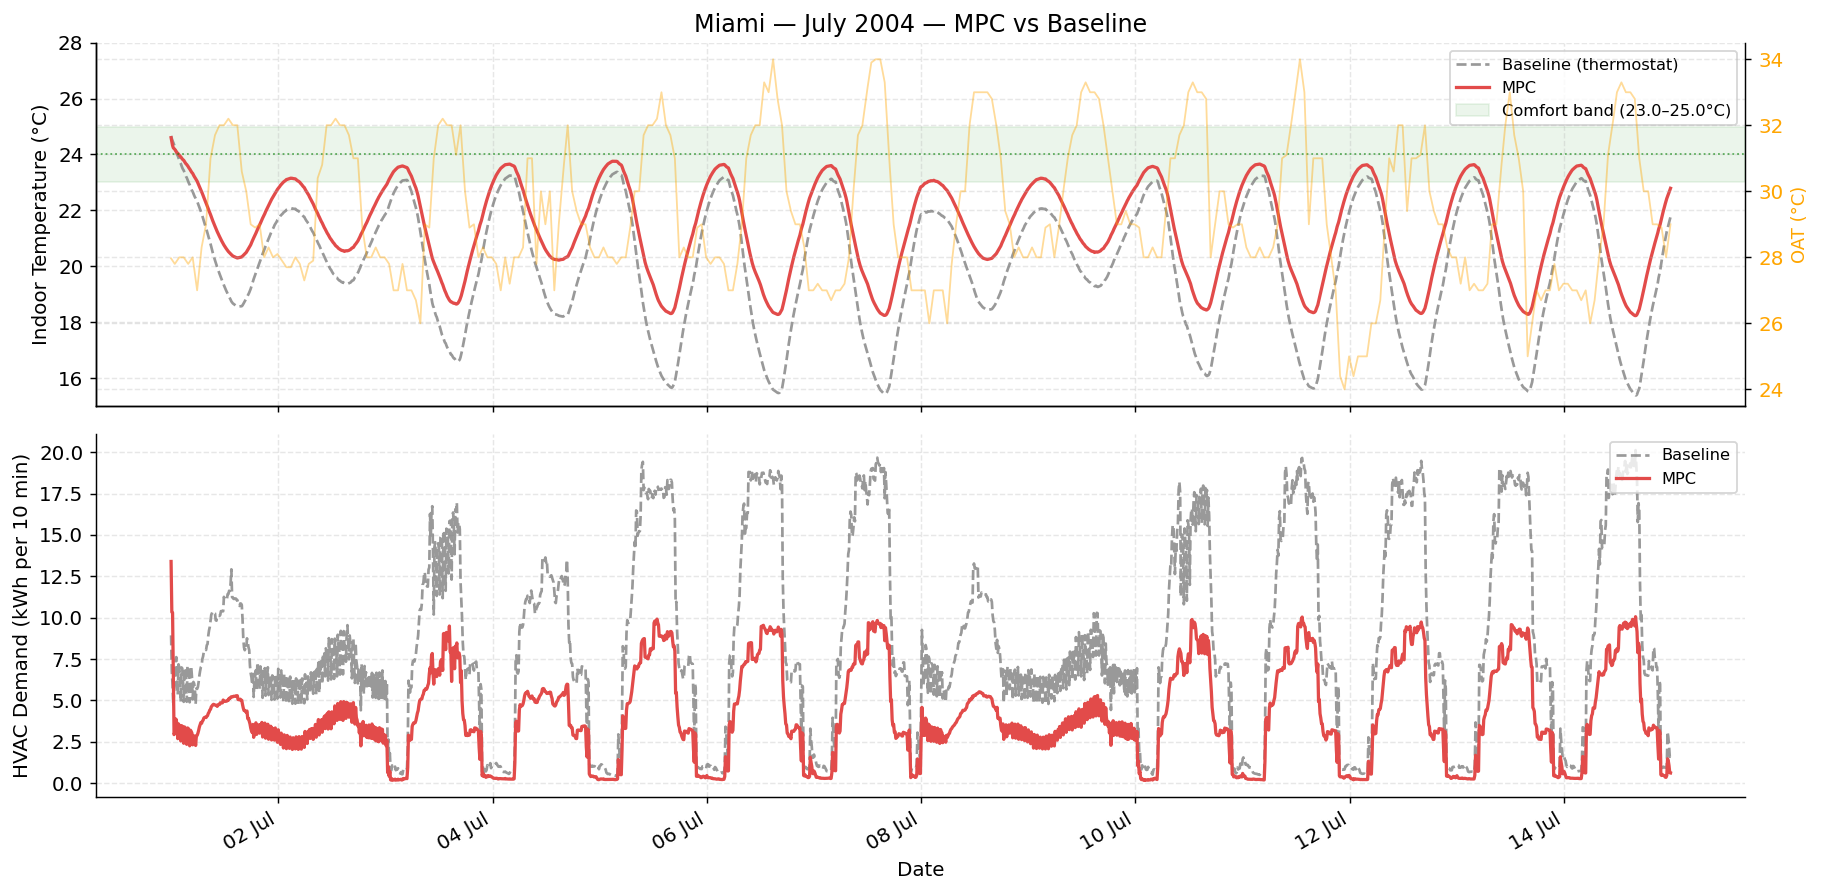

Saved → figures/05_timeseries_1A_summer.png


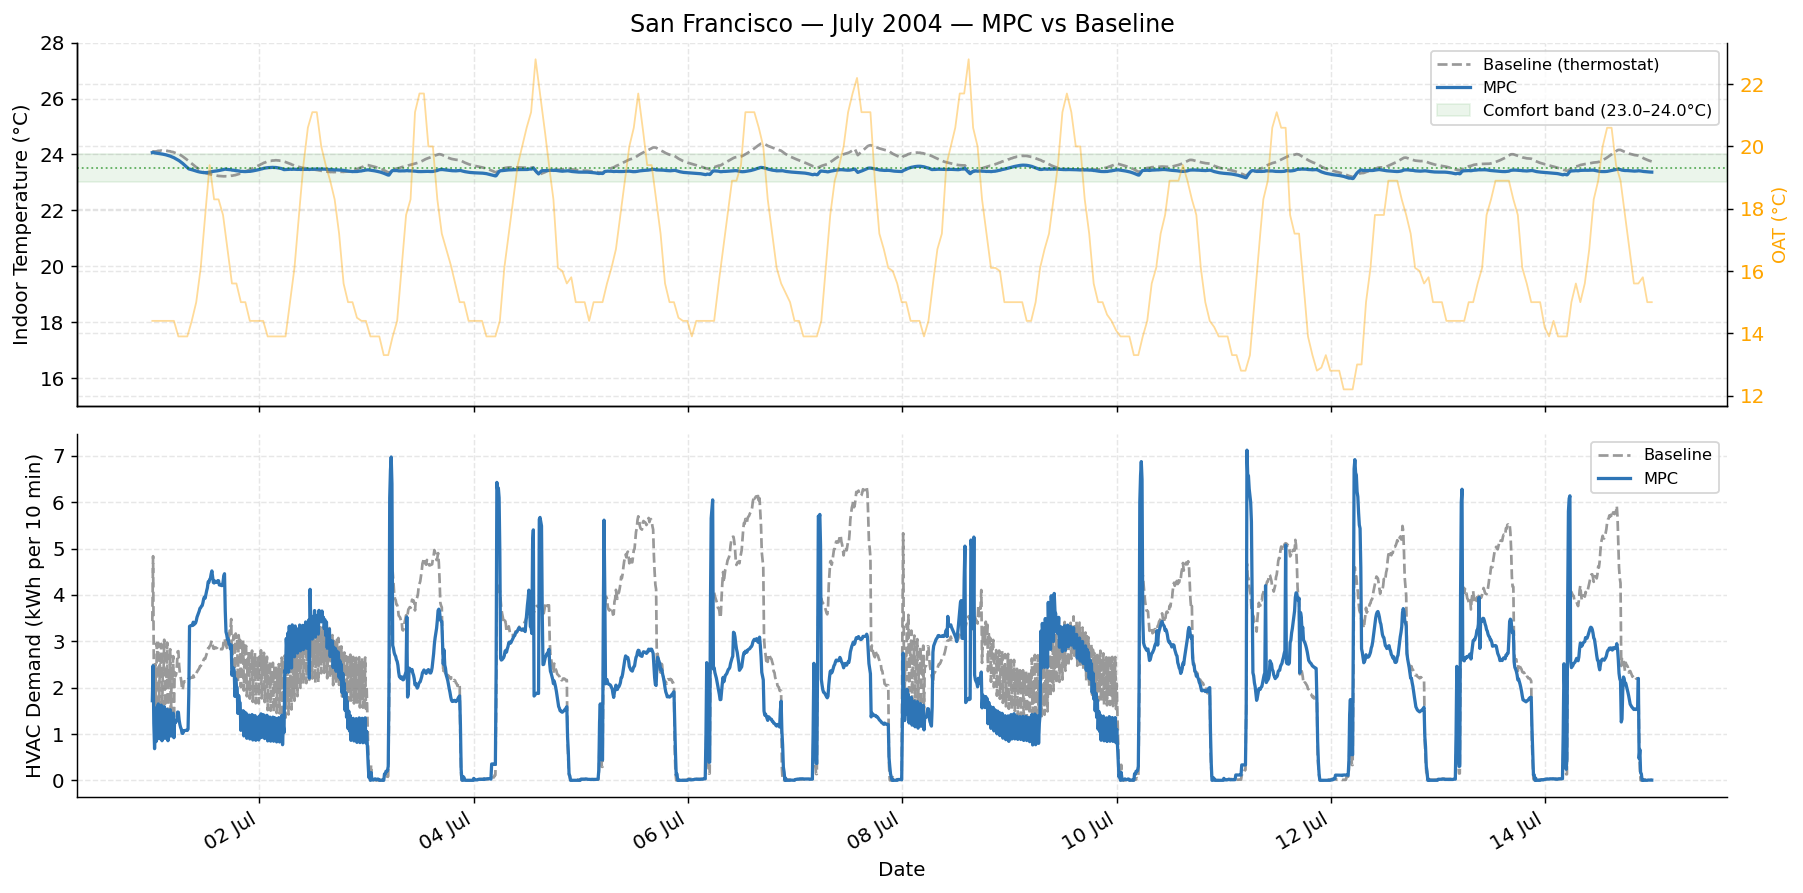

Saved → figures/05_timeseries_3C_summer.png


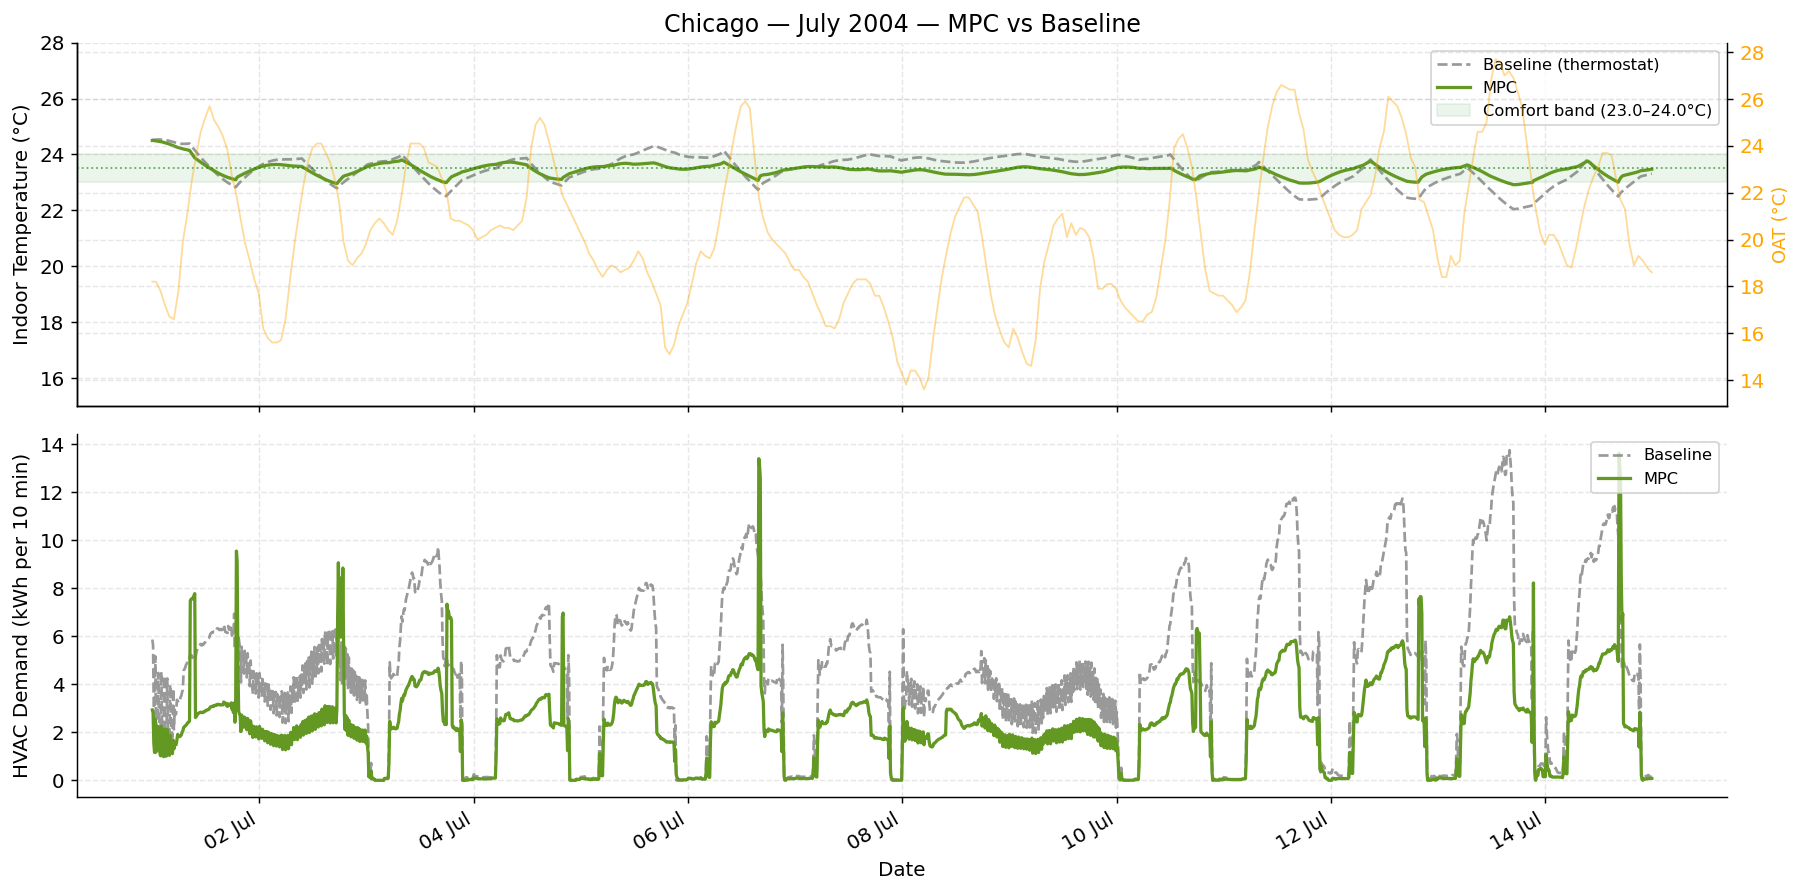

Saved → figures/05_timeseries_5A_summer.png


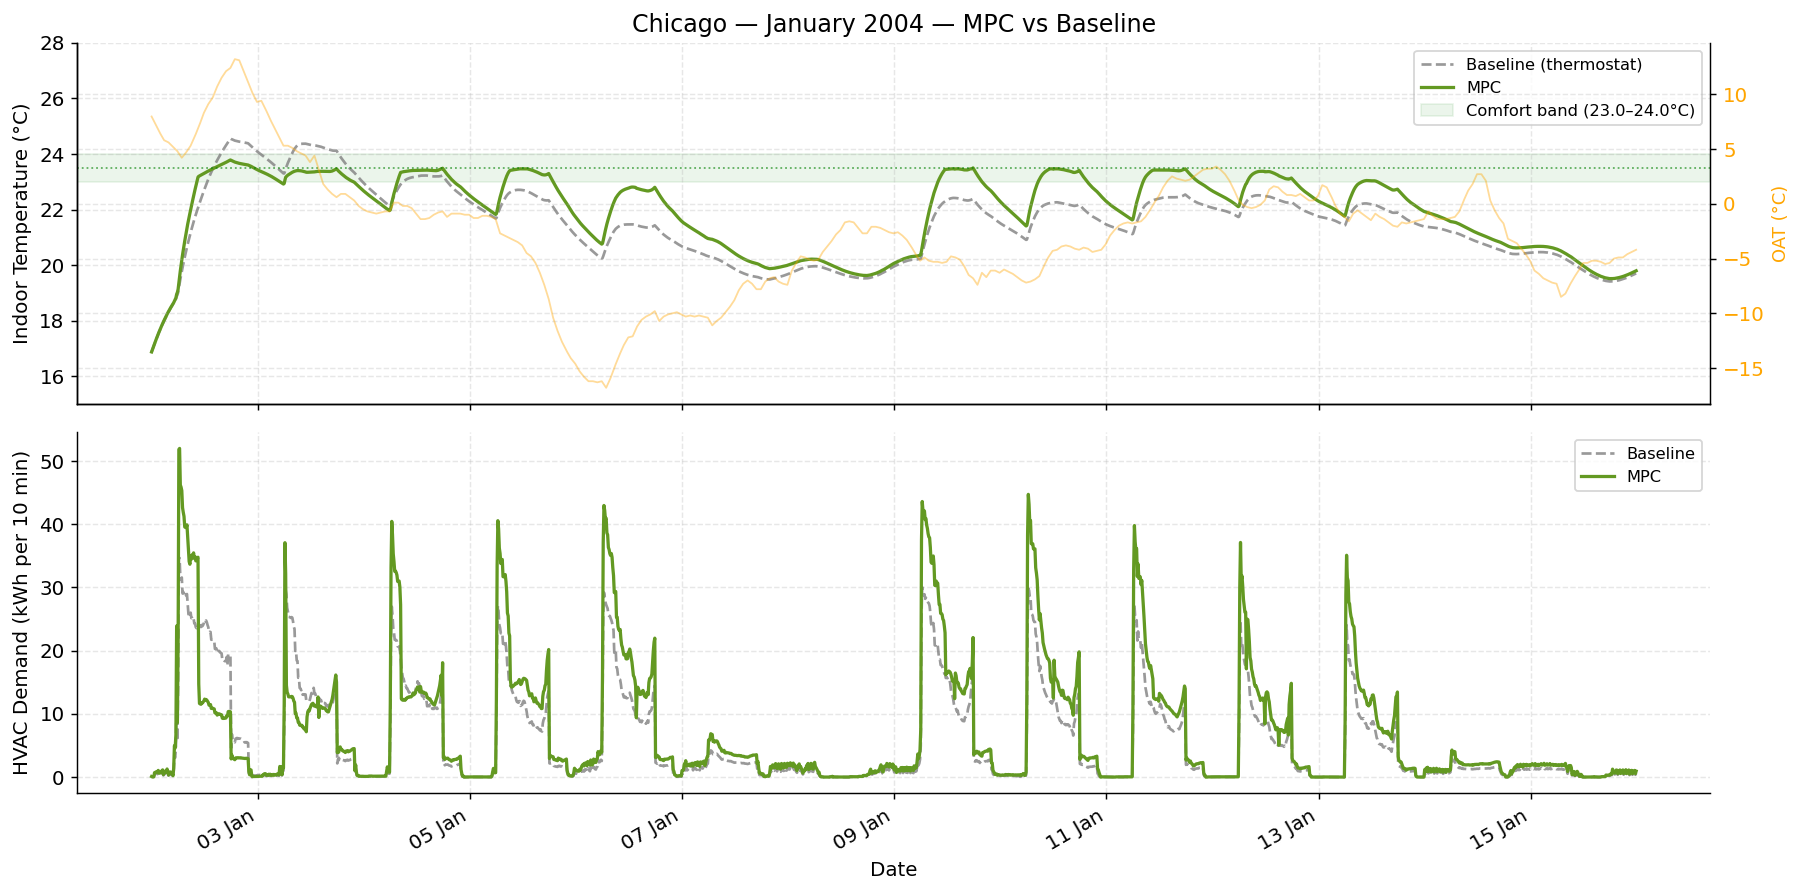

Saved → figures/05_timeseries_5A_winter.png


In [13]:
for cfg in SIM_WINDOWS:
    key   = f"{cfg['climate']}_{cfg['season']}"
    base  = baseline_results[key]
    mpc   = mpc_results[key]
    clim  = cfg['climate']
    col   = CLIMATE_COLOURS[clim]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # ── Top: Indoor temperature ───────────────────────────────────────────────
    ax1.plot(base.index, base['indoor_temp_c'], '--', color='grey',
             alpha=0.8, lw=1.5, label='Baseline (thermostat)')
    ax1.plot(mpc.index, mpc['indoor_temp_c'], '-', color=col,
             lw=1.8, label='MPC')
    c_low, c_high = COMFORT_BANDS[clim]
    sp = SETPOINTS.get(clim, SETPOINT)
    ax1.axhspan(c_low, c_high, alpha=0.08, color='green', label=f'Comfort band ({c_low}–{c_high}°C)')
    ax1.axhline(sp, color='green', ls=':', lw=1, alpha=0.6)

    # OAT on twin axis
    ax1_twin = ax1.twinx()
    ax1_twin.plot(base.index, base['oat_c'], color='orange', alpha=0.4, lw=1, label='OAT')
    ax1_twin.set_ylabel('OAT (°C)', color='orange', fontsize=10)
    ax1_twin.tick_params(axis='y', labelcolor='orange')
    ax1_twin.spines['right'].set_visible(True)

    ax1.set_ylabel('Indoor Temperature (°C)')
    ax1.set_ylim(min(15, mpc['indoor_temp_c'].min() - 1),
                 max(28, mpc['indoor_temp_c'].max() + 1))
    lines1, labs1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1, labs1, loc='upper right', fontsize=9)
    ax1.set_title(f"{cfg['label']} — MPC vs Baseline")

    # ── Bottom: HVAC energy ───────────────────────────────────────────────────
    ax2.plot(base.index, base['hvac_kwh'], '--', color='grey', alpha=0.8,
             lw=1.5, label='Baseline')
    ax2.plot(mpc.index, mpc['hvac_kwh'], '-', color=col, lw=1.8, label='MPC')
    ax2.set_ylabel('HVAC Demand (kWh per 10 min)')
    ax2.set_xlabel('Date')
    ax2.legend(loc='upper right', fontsize=9)

    # x-axis formatting
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    fname = f"05_timeseries_{clim}_{cfg['season']}.png"
    fig.savefig(FIG_OUT / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → figures/{fname}')

In [14]:
# ── Summary metrics table ─────────────────────────────────────────────────────
rows = []
for cfg in SIM_WINDOWS:
    key = f"{cfg['climate']}_{cfg['season']}"
    bm  = compute_metrics(baseline_results[key], clim=cfg['climate'])
    mm  = compute_metrics(mpc_results[key], clim=cfg['climate'])
    saved_pct = 100 * (bm['total_hvac_kwh'] - mm['total_hvac_kwh']) / bm['total_hvac_kwh']
    rows.append({
        'Window'              : cfg['label'],
        'Base Energy (kWh)'   : round(bm['total_hvac_kwh'], 1),
        'MPC Energy (kWh)'    : round(mm['total_hvac_kwh'], 1),
        'Energy Saved (%)'    : round(saved_pct, 2),
        'Base Temp Dev (°C)'  : round(bm['mean_abs_temp_dev'], 4),
        'MPC Temp Dev (°C)'   : round(mm['mean_abs_temp_dev'], 4),
        'Base Viol (%)'       : round(bm['comfort_violation_pct'], 2),
        'MPC Viol (%)'        : round(mm['comfort_violation_pct'], 2),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

                   Window  Base Energy (kWh)  MPC Energy (kWh)  Energy Saved (%)  Base Temp Dev (°C)  MPC Temp Dev (°C)  Base Viol (%)  MPC Viol (%)
        Miami — July 2004            17215.4            8253.7             52.06              4.0244             2.6088          91.67         77.38
San Francisco — July 2004             5213.3            3929.3             24.63              0.2356             0.1004          13.14          0.84
      Chicago — July 2004             9209.5            4885.6             46.95              0.4201             0.1816          27.58          6.00
   Chicago — January 2004            11667.7           14788.2            -26.74              2.0767             1.5384          92.36         68.45


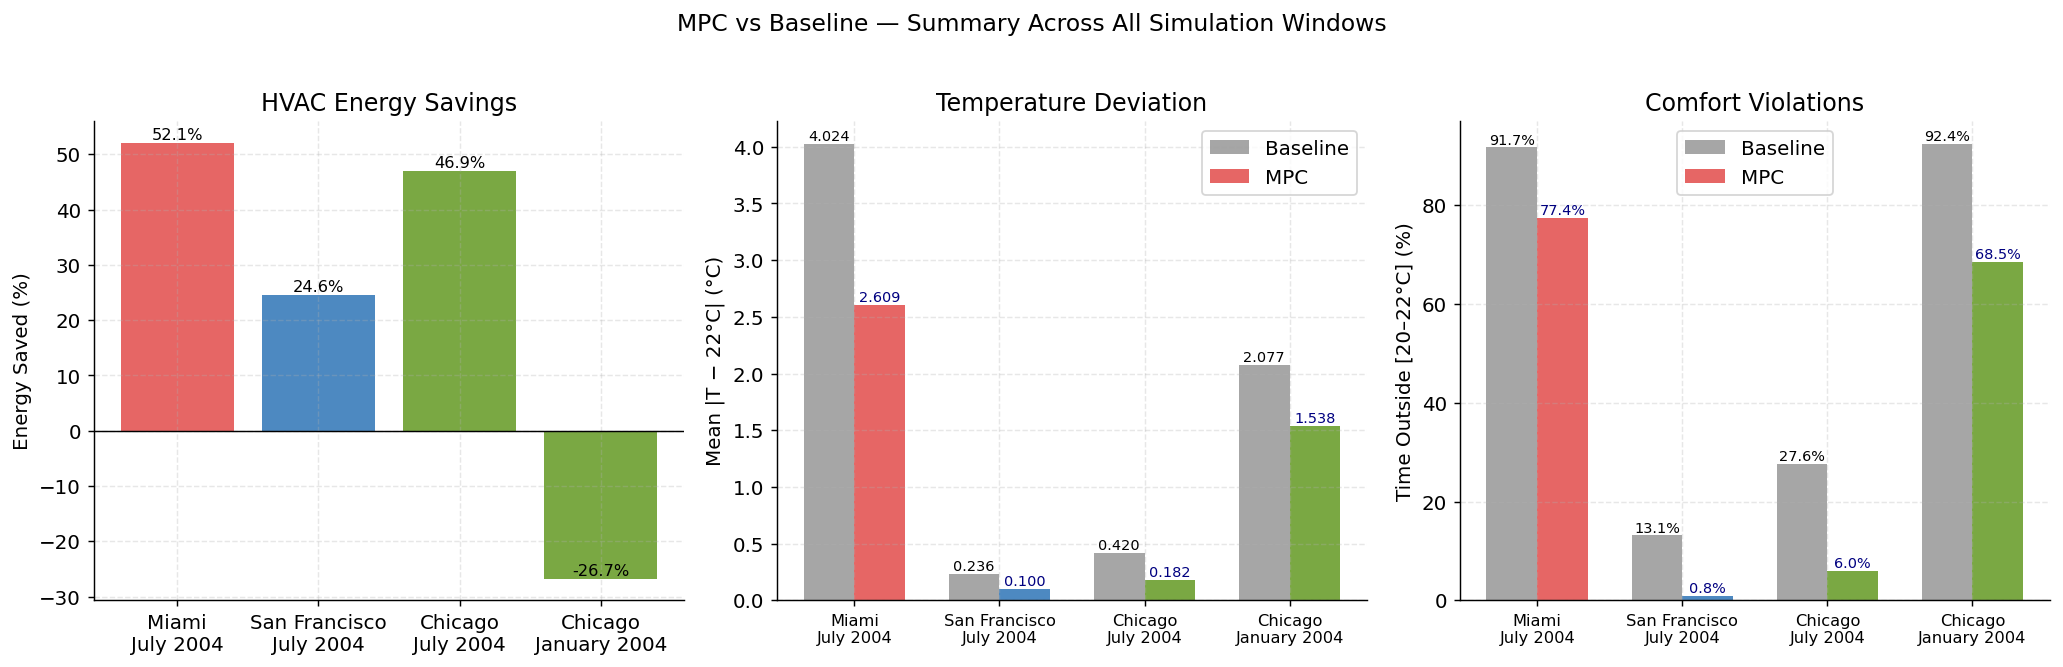

Saved → figures/05_summary_barcharts.png


In [15]:
# ── Summary bar charts ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = [cfg['label'].replace(' — ', '\n') for cfg in SIM_WINDOWS]
clim_cols = [CLIMATE_COLOURS[cfg['climate']] for cfg in SIM_WINDOWS]

keys = [f"{cfg['climate']}_{cfg['season']}" for cfg in SIM_WINDOWS]
bms  = [compute_metrics(baseline_results[k], clim=c['climate']) for k, c in zip(keys, SIM_WINDOWS)]
mms  = [compute_metrics(mpc_results[k],      clim=c['climate']) for k, c in zip(keys, SIM_WINDOWS)]

# Energy saved
saved = [100*(b['total_hvac_kwh']-m['total_hvac_kwh'])/b['total_hvac_kwh']
         for b, m in zip(bms, mms)]
bars = axes[0].bar(labels, saved, color=clim_cols, alpha=0.85)
for bar, v in zip(bars, saved):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Energy Saved (%)')
axes[0].set_title('HVAC Energy Savings')
axes[0].axhline(0, color='k', lw=0.8)

# Temperature deviation
x = np.arange(len(SIM_WINDOWS))
w = 0.35
axes[1].bar(x - w/2, [b['mean_abs_temp_dev'] for b in bms], w, label='Baseline',
            color='grey', alpha=0.7)
axes[1].bar(x + w/2, [m['mean_abs_temp_dev'] for m in mms], w, label='MPC',
            color=clim_cols, alpha=0.85)
for i, (b, m) in enumerate(zip(bms, mms)):
    axes[1].text(i - w/2, b['mean_abs_temp_dev'] + 0.001, f'{b["mean_abs_temp_dev"]:.3f}',
                 ha='center', va='bottom', fontsize=8)
    axes[1].text(i + w/2, m['mean_abs_temp_dev'] + 0.001, f'{m["mean_abs_temp_dev"]:.3f}',
                 ha='center', va='bottom', fontsize=8, color='navy')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylabel('Mean |T − 22°C| (°C)')
axes[1].set_title('Temperature Deviation')
axes[1].legend()

# Comfort violations
axes[2].bar(x - w/2, [b['comfort_violation_pct'] for b in bms], w, label='Baseline',
            color='grey', alpha=0.7)
axes[2].bar(x + w/2, [m['comfort_violation_pct'] for m in mms], w, label='MPC',
            color=clim_cols, alpha=0.85)
for i, (b, m) in enumerate(zip(bms, mms)):
    axes[2].text(i - w/2, b['comfort_violation_pct'] + 0.05, f'{b["comfort_violation_pct"]:.1f}%',
                 ha='center', va='bottom', fontsize=8)
    axes[2].text(i + w/2, m['comfort_violation_pct'] + 0.05, f'{m["comfort_violation_pct"]:.1f}%',
                 ha='center', va='bottom', fontsize=8, color='navy')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, fontsize=9)
axes[2].set_ylabel('Time Outside [20–22°C] (%)')
axes[2].set_title('Comfort Violations')
axes[2].legend()

plt.suptitle('MPC vs Baseline — Summary Across All Simulation Windows', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIG_OUT / '05_summary_barcharts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/05_summary_barcharts.png')

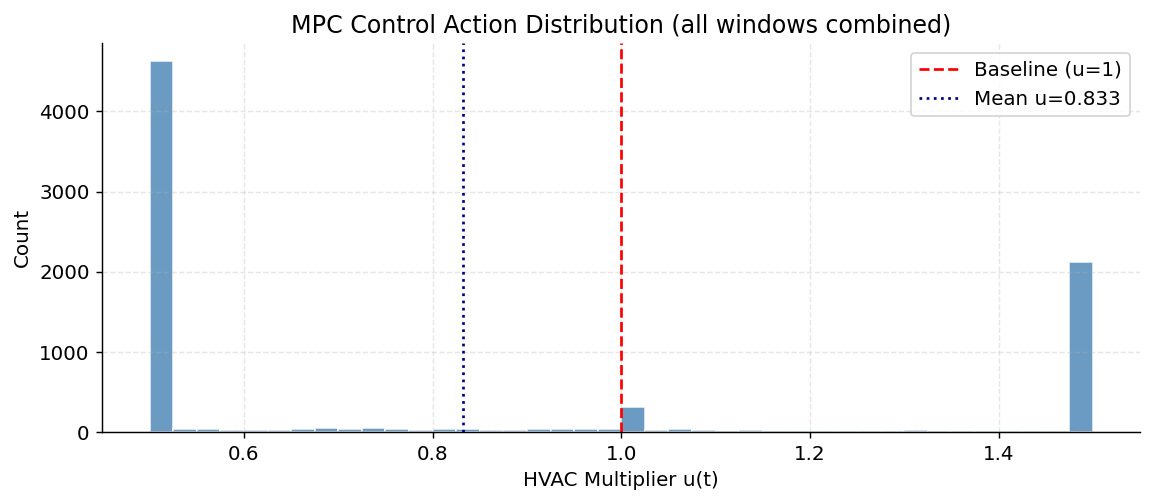

u distribution: mean=0.8326, std=0.4360, min=0.5000, max=1.5000
Saved → figures/05_u_distribution.png


In [16]:
# ── MPC control action distribution ─────────────────────────────────────────
all_u = pd.concat([mpc_results[f"{cfg['climate']}_{cfg['season']}"]
                   for cfg in SIM_WINDOWS])['u']

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_u, bins=40, range=(U_MIN, U_MAX), color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Baseline (u=1)')
ax.set_xlabel('HVAC Multiplier u(t)')
ax.set_ylabel('Count')
ax.set_title('MPC Control Action Distribution (all windows combined)')
ax.legend()

mean_u = float(all_u.mean())
ax.axvline(mean_u, color='navy', ls=':', lw=1.5, label=f'Mean u={mean_u:.3f}')
ax.legend()

plt.tight_layout()
fig.savefig(FIG_OUT / '05_u_distribution.png', dpi=150)
plt.show()
print(f'u distribution: mean={mean_u:.4f}, std={all_u.std():.4f}, '
      f'min={all_u.min():.4f}, max={all_u.max():.4f}')
print('Saved → figures/05_u_distribution.png')

## 9. Save Results

In [17]:
output = {
    'mpc_config': {
        'horizon_steps': MPC_HORIZON,
        'w_temp'       : W_TEMP,
        'w_energy'     : W_ENERGY,
        'u_bounds'     : [U_MIN, U_MAX],
        'optimizer'    : 'L-BFGS-B',
        'comfort_band' : [COMFORT_LOW, COMFORT_HIGH],
        'setpoint_c'   : SETPOINT,
    },
    'rc_models': {
        clim: {k: v for k, v in m.items()}
        for clim, m in rc_models.items()
    },
    'simulation_results': {},
}

for cfg in SIM_WINDOWS:
    key = f"{cfg['climate']}_{cfg['season']}"
    bm  = compute_metrics(baseline_results[key])
    mm  = compute_metrics(mpc_results[key])
    saved_pct = 100 * (bm['total_hvac_kwh'] - mm['total_hvac_kwh']) / bm['total_hvac_kwh']
    output['simulation_results'][key] = {
        'label'   : cfg['label'],
        'n_steps' : len(baseline_results[key]),
        'baseline': bm,
        'mpc'     : {**mm, 'mean_u': float(mpc_results[key]['u'].mean())},
        'energy_saved_pct': round(saved_pct, 4),
    }

results_path = DATA_IN / 'mpc_results.json'
with open(results_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f'Saved → {results_path}')

Saved → ../data/processed/mpc_results.json


## 10. Summary

### ML Dynamics Model — Feature Importance
*(fill in after running)*

### RC Thermal Model Coefficients (Section 4 — for comparison)
*(fill in after running)*

| Climate | α_env | β_cool | β_heat | γ_occ | δ_hs | δ_hc | R² |
|---------|-------|--------|--------|-------|------|------|----|
| Miami (1A) | — | — | — | — | — | — | — |
| San Francisco (3C) | — | — | — | — | — | — | — |
| Chicago (5A) | — | — | — | — | — | — | — |

### MPC Results Summary
*(fill in after running)*

| Simulation window | Baseline HVAC | MPC HVAC | Energy saving | Baseline viol% | MPC viol% |
|-------------------|--------------|----------|---------------|----------------|----------|
| Miami — July | — | — | — | — | — |
| SF — July | — | — | — | — | — |
| Chicago — July | — | — | — | — | — |
| Chicago — January | — | — | — | — | — |

### Architecture
- **HVAC predictor:** XGBoost v2 (`model_xgb_v2.pkl`) — 32 features → `hvac_kwh` demand
- **Dynamics model:** XGBoost per climate (`ml_dynamics_*.pkl`) — 9 features → `T(t+1)`
- **MPC optimiser:** `scipy.minimize` L-BFGS-B, horizon H=12 (120 min), W_temp=50, W_energy=1
- **Control variable:** u ∈ [0.5, 1.5] multiplying HVAC baseline
